## XGBoost Regressor

El **XGBoost Regressor** es un método de gradient boosting que construye
árboles de decisión de forma secuencial, donde cada árbol corrige los errores
residuales del conjunto anterior. A diferencia del Random Forest (bagging en
paralelo), XGBoost aprende iterativamente — cada ronda de boosting se enfoca
en los ejemplos más difíciles de predecir, reduciendo especialmente los errores
extremos. Incorpora regularización L1/L2 nativa sobre los pesos de las hojas
y construcción eficiente via histogramas (`tree_method='hist'`).

**¿Por qué XGBoost para RUL?**
El boosting secuencial tiene una propiedad particularmente relevante para RUL:
al enfocarse iterativamente en los errores más grandes — que en este contexto
son las sobreestimaciones tardías del RUL — reduce exactamente el tipo de error
que más penaliza el S-Score NASA. Esto lo distingue de RF (reduce varianza
uniformemente) y SVR (minimiza error cuadrático dentro del tubo ε sin
distinción de dirección).

**Abordaje en este proyecto**
Recibe la salida del pipeline Nodos 2-4. `n_jobs=1` está fijo internamente
para evitar conflictos con el paralelismo externo del GGS. `objective=
'reg:squarederror'` y `tree_method='hist'` también son fijos — MSE como
criterio de optimización y construcción eficiente por histogramas.

**Hiperparámetros considerados**

| Hiperparámetro | Rango explorado | Justificación |
|----------------|----------------|---------------|
| `feature_set` | A, B, C, D | Evalúa el impacto del set de features sobre el boosting |
| `window_size` | 20, 25, 30 | Horizonte temporal de cada ventana |
| `n_components` | 10, 15, 20 | Dimensionalidad del espacio de boosting |
| `clipping_threshold` | 115, 120, 125 | Techo del espacio predictivo piecewise |
| `n_estimators` | 100, 200, 300 | Número de rondas de boosting |
| `learning_rate` | 0.05, 0.10 | Shrinkage por ronda — controla velocidad de aprendizaje |
| `max_depth` | 3, 5 | Profundidad máxima por árbol base |
| `subsample` | 0.8, 1.0 | Fracción de ventanas por ronda de boosting |
| `colsample_bytree` | 0.8, 1.0 | Fracción de componentes PCA por árbol |
| `reg_lambda` | 0.1, 1.0, 10.0 | Regularización L2 sobre pesos de hojas |
| `min_child_weight` | 1, 5 | Mínimo de peso en nodos hoja |

## Resultados GGS y selección de hiperparámetros

**Resumen del GGS**
- Configuraciones evaluadas: 31,104 — exitosas: 31,076 — fallidas: 28 (0.09%)
- Folds: 5 (GroupKFold por motor)

**Top 10 configuraciones**

| feature_set | window_size | n_components | clipping_threshold | n_estimators | learning_rate | max_depth | subsample | colsample_bytree | reg_lambda | min_child_weight | S-Score | MAE | RMSE | C-Index |
|-------------|-------------|--------------|-------------------|--------------|---------------|-----------|-----------|-----------------|------------|-----------------|---------|-----|------|---------|
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 1.0 | 1.0 | 0.1 | 5 | 1.782 | 7.10 | 10.45 | 0.912 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 0.8 | 0.8 | 10.0 | 5 | 1.786 | 7.11 | 10.42 | 0.912 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 1.0 | 1.0 | 1.0 | 1 | 1.789 | 7.10 | 10.46 | 0.912 |
| A | 30 | 10 | 115 | 200 | 0.10 | 3 | 0.8 | 0.8 | 10.0 | 5 | 1.790 | 7.12 | 10.43 | 0.913 |
| A | 30 | 10 | 115 | 200 | 0.10 | 3 | 0.8 | 0.8 | 0.1 | 5 | 1.791 | 7.13 | 10.46 | 0.912 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 1.0 | 1.0 | 1.0 | 5 | 1.792 | 7.11 | 10.47 | 0.912 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 0.8 | 0.8 | 0.1 | 5 | 1.792 | 7.15 | 10.46 | 0.911 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 1.0 | 1.0 | 10.0 | 5 | 1.792 | 7.09 | 10.45 | 0.912 |
| A | 30 | 10 | 115 | 300 | 0.10 | 3 | 1.0 | 1.0 | 10.0 | 1 | 1.792 | 7.08 | 10.44 | 0.912 |
| A | 30 | 15 | 115 | 100 | 0.05 | 5 | 0.8 | 0.8 | 1.0 | 1 | 1.793 | 7.11 | 10.40 | 0.914 |

### Análisis de configuraciones fallidas

Las 28 configuraciones fallidas (0.09%) presentan un patrón determinista:
todas comparten `learning_rate=0.05` + `n_estimators=100` + `window_size=25`
+ `n_components=20`. La combinación de learning rate bajo con pocas rondas
de boosting produce capacidad insuficiente para ajustarse al espacio de 20
componentes PCA, generando predicciones degeneradas en algún fold.
Este resultado confirma la superioridad de `learning_rate=0.10` y valida
la exclusión de estas configuraciones del análisis.

### Conclusiones

**Pipeline**
- `window_size=30` y `clipping_threshold=115` — quinto modelo consecutivo
  que confirma estos valores como parámetros robustos del dataset.
- `feature_set=A` y `n_components=10` — quinto modelo que confirma el espacio
  PCA compacto como óptimo para modelos basados en particiones del espacio
  de features.

**Modelo**
- `learning_rate=0.10` — exclusivo en las primeras 9 posiciones. Con `max_depth=3`
  y suficientes estimadores, lr=0.10 converge a mejor solución que lr=0.05.
- `max_depth=3` — árboles muy superficiales dominan el top. XGBoost con boosting
  secuencial prefiere modelos base débiles que se corrigen iterativamente —
  contrasta con RF donde `max_depth=10` era óptimo.
- `min_child_weight=5` — domina 7 de las 10 primeras posiciones. Nodos con
  peso mínimo de 5 evitan splits sobre regiones con poca representatividad.
- `subsample`, `colsample_bytree`, `reg_lambda` — sin patrón claro. Distribución
  uniforme en exitosas vs fallidas confirma que son irrelevantes para este dataset.
  Se fijan en sus valores más simples y neutros.

### Comparación acumulada

| Métrica | NB | DT | RF | SVR | **XGB** |
|---------|----|----|-----|-----|---------|
| S-Score | 2.447 | 2.755 | 1.883 | 1.825 | **1.782** |
| MAE | 10.39 | 7.79 | 6.98 | **6.75** | 7.10 |
| RMSE | 13.36 | 12.22 | 10.62 | **10.24** | 10.45 |
| C-Index | 0.908 | 0.893 | 0.909 | **0.915** | 0.912 |

XGBoost lidera en S-Score pero no domina en MAE/RMSE/C-Index. El boosting
secuencial reduce especialmente las sobreestimaciones tardías — el error más
penalizado por el S-Score NASA — sin reducir el error absoluto promedio tanto
como SVR. El ranking definitivo entre XGB y SVR se resolverá con el test set.

### Hiperparámetros seleccionados para producción

```python
best_params_xgb = {
    # Pipeline
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    # Modelo
    'n_estimators':       200,
    'learning_rate':      0.1,
    'max_depth':          3,
    'subsample':          1.0,
    'colsample_bytree':   1.0,
    'reg_lambda':         1.0,
    'min_child_weight':   5,
}
```

`n_estimators=200` sobre 300 aplica el mismo principio de rendimientos
decrecientes observado en RF — diferencia de 0.007 en S-Score por 50% más
de cómputo. `subsample=1.0` y `colsample_bytree=1.0` producen un modelo
**determinista**: dados el mismo dataset y `random_state=42`, las predicciones
son idénticas en cada ejecución — propiedad deseable en sistemas de
mantenimiento predictivo donde la auditabilidad es crítica. `reg_lambda=1.0`
es el default de XGBoost, calibrado como punto de equilibrio entre bias y
varianza sin evidencia en el GGS para alejarse de él.

In [1]:
import pandas as pd

results_path = 'outputs/ggs/results/XGBModel_43704765_20260511_1444.csv'

cols_params = ['feature_set', 'window_size', 'n_components', 'clipping_threshold', 
               'n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 
               'reg_lambda', 'min_child_weight', 'mean_S_score', 'mean_C_index', 'mean_MAE', 
               'mean_RMSE']

df_results = pd.read_csv(results_path)

total = len(df_results)
exitosas = df_results['mean_S_score'].notna().sum()
fallidas = df_results['mean_S_score'].isna().sum()
n_duplicados = df_results.duplicated(subset=cols_params).sum()

print(f"Total configuraciones: {total}")
print(f"Exitosas:              {exitosas}")
print(f"Fallidas (NaN):        {fallidas}")
print(f"Duplicados:            {n_duplicados}")
print(f"Únicas:                {total - n_duplicados}")

Total configuraciones: 31104
Exitosas:              31076
Fallidas (NaN):        28
Duplicados:            0
Únicas:                31104


In [3]:
df_top = (
    df_results
    .dropna(subset=['mean_S_score'])
    .sort_values('mean_S_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

df_top[cols_params]

,feature_set,window_size,n_components,clipping_threshold,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,reg_lambda,min_child_weight,mean_S_score,mean_C_index,mean_MAE,mean_RMSE
0,A,30,10,115,300,0.10,3,1.0,1.0,0.1,5,1.782339,0.912280,7.096352,10.450048
1,A,30,10,115,300,0.10,3,0.8,0.8,10.0,5,1.785607,0.912034,7.112294,10.420613
2,A,30,10,115,300,0.10,3,1.0,1.0,1.0,1,1.789015,0.912452,7.103761,10.461413
3,A,30,10,115,200,0.10,3,0.8,0.8,10.0,5,1.789890,0.912937,7.119702,10.431387
4,A,30,10,115,200,0.10,3,0.8,0.8,0.1,5,1.791486,0.912326,7.127622,10.455702
5,A,30,10,115,300,0.10,3,1.0,1.0,1.0,5,1.792337,0.912006,7.113119,10.470224
6,A,30,10,115,300,0.10,3,0.8,0.8,0.1,5,1.792370,0.911316,7.146037,10.463624
7,A,30,10,115,300,0.10,3,1.0,1.0,10.0,5,1.792403,0.912306,7.091080,10.447014
8,A,30,10,115,300,0.10,3,1.0,1.0,10.0,1,1.792430,0.912445,7.084765,10.444758
9,A,30,15,115,100,0.05,5,0.8,0.8,1.0,1,1.792568,0.913687,7.110839,10.403835


In [2]:
# ── Celda: Análisis de configuraciones fallidas ───────────────────────────
df_failed = df_results[df_results['mean_S_score'].isna()].copy()

print(f"Configuraciones fallidas: {len(df_failed)}")
print(f"Porcentaje: {100*len(df_failed)/len(df_results):.2f}%\n")

# Distribución por hiperparámetro
params_modelo = ['n_estimators', 'learning_rate', 'max_depth', 
                 'subsample', 'colsample_bytree', 'reg_lambda', 'min_child_weight']

for param in params_modelo:
    dist = df_failed[param].value_counts().sort_index()
    print(f"{param}:")
    print(dist.to_string())
    print()

Configuraciones fallidas: 28
Porcentaje: 0.09%

n_estimators:
n_estimators
100    28

learning_rate:
learning_rate
0.05    28

max_depth:
max_depth
3    20
5     8

subsample:
subsample
0.8    16
1.0    12

colsample_bytree:
colsample_bytree
0.8    14
1.0    14

reg_lambda:
reg_lambda
0.1     10
1.0      8
10.0    10

min_child_weight:
min_child_weight
1    14
5    14



In [3]:
# ── Celda: Comparar distribución fallidas vs exitosas ────────────────────
df_ok = df_results[df_results['mean_S_score'].notna()].copy()

print("Distribución comparada (fallidas vs exitosas):\n")
for param in params_modelo:
    pct_failed = df_failed[param].value_counts(normalize=True).sort_index() * 100
    pct_ok     = df_ok[param].value_counts(normalize=True).sort_index() * 100
    comparison = pd.DataFrame({
        'fallidas_%': pct_failed,
        'exitosas_%': pct_ok,
    }).fillna(0).round(1)
    print(f"{param}:")
    print(comparison.to_string())
    print()

Distribución comparada (fallidas vs exitosas):

n_estimators:
              fallidas_%  exitosas_%
n_estimators                        
100                100.0        33.3
200                  0.0        33.4
300                  0.0        33.4

learning_rate:
               fallidas_%  exitosas_%
learning_rate                        
0.05                100.0        50.0
0.10                  0.0        50.0

max_depth:
           fallidas_%  exitosas_%
max_depth                        
3                71.4        50.0
5                28.6        50.0

subsample:
           fallidas_%  exitosas_%
subsample                        
0.8              57.1        50.0
1.0              42.9        50.0

colsample_bytree:
                  fallidas_%  exitosas_%
colsample_bytree                        
0.8                     50.0        50.0
1.0                     50.0        50.0

reg_lambda:
            fallidas_%  exitosas_%
reg_lambda                        
0.1               35.7 

In [4]:
# ── Celda: ¿Las fallidas se concentran en combinaciones específicas? ──────
print("Combinaciones más frecuentes en fallidas:\n")
cols_combo = ['learning_rate', 'max_depth', 'n_estimators']
print(df_failed.groupby(cols_combo).size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .head(10)
      .to_string(index=False))

Combinaciones más frecuentes en fallidas:

 learning_rate  max_depth  n_estimators  count
          0.05          3           100     20
          0.05          5           100      8


In [5]:
# ── Celda: Pipeline params en fallidas ───────────────────────────────────
print("Pipeline params en fallidas:\n")
for param in ['feature_set', 'window_size', 'n_components', 'clipping_threshold']:
    dist = df_failed[param].value_counts().sort_index()
    print(f"{param}:")
    print(dist.to_string())
    print()

Pipeline params en fallidas:

feature_set:
feature_set
A    28

window_size:
window_size
25    28

n_components:
n_components
20    28

clipping_threshold:
clipping_threshold
120    28



In [1]:
from src.models.xgb_model import XGBModel
from src.utils.production_predictor import RULProductionPredictor

best_params_xgb = {
    # Pipeline
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    # Modelo
    'n_estimators':       200,
    'learning_rate':      0.1,
    'max_depth':          3,
    'subsample':          1.0,
    'colsample_bytree':   1.0,
    'reg_lambda':         1.0,
    'min_child_weight':   5,
}

predictor_dt = RULProductionPredictor.from_config(
    model_class=XGBModel,
    params=best_params_xgb,
)

print(f"model_name_:        {predictor_dt.model_name_}")
print(f"feature_set:        {predictor_dt.feature_set}")
print(f"window_size:        {predictor_dt.window_size}")
print(f"n_components:       {predictor_dt.n_components}")
print(f"clipping_threshold: {predictor_dt.clipping_threshold}")
print(f"pipeline fitted:    {predictor_dt.pipeline_.is_fitted_}")
print(f"model fitted:       {getattr(predictor_dt.model_, 'is_fitted_', False)}")

Training engines: 140
Test engines: 60
model_name_:        XGBModel
feature_set:        A
window_size:        30
n_components:       10
clipping_threshold: 115
pipeline fitted:    True
model fitted:       True


In [2]:
session_dt = predictor_dt.save()

print(f"\nstem:     {session_dt.stem}")
print(f"modelo:   {session_dt.path_model}")
print(f"metadata: {session_dt.path_metadata}")

  ✅ Predictor saved: XGBModel_A_30w_10pc_20260513_1317.pkl
  📄 Metadata saved: XGBModel_A_30w_10pc_20260513_1317.json

stem:     XGBModel_A_30w_10pc_20260513_1317
modelo:   outputs/production/models/XGBModel_A_30w_10pc_20260513_1317.pkl
metadata: outputs/production/metadata/XGBModel_A_30w_10pc_20260513_1317.json


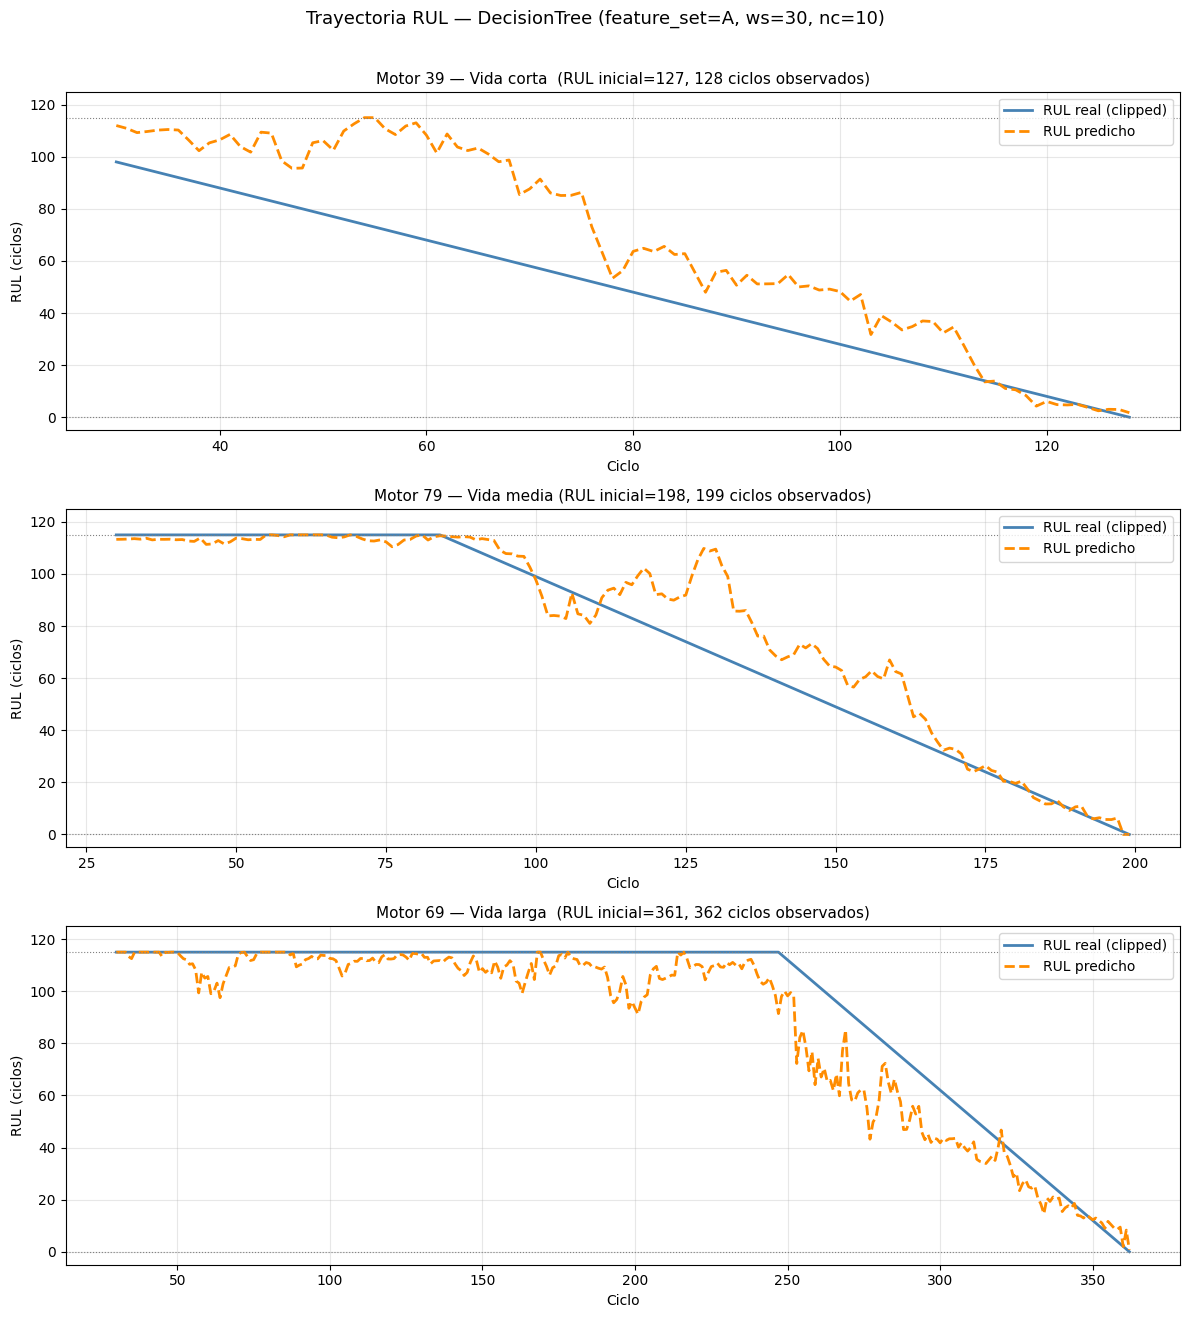

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

for ax, (motor_id, titulo) in zip(axes, motores):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])

    _, _, t_stop_m, _, _ = predictor_dt.pipeline_.transform(X_m)
    rul_pred_m = predictor_dt.predict(X_m, return_mode='all')

    rul_real_m = np.minimum(
        df_m['RUL'].values[predictor_dt.window_size - 1:],
        predictor_dt.clipping_threshold,
    )

    ax.plot(t_stop_m, rul_real_m, label='RUL real (clipped)', color='steelblue',  linewidth=2)
    ax.plot(t_stop_m, rul_pred_m, label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
    ax.axhline(y=0,                           color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=predictor_dt.clipping_threshold, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=11)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, predictor_dt.clipping_threshold + 10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Trayectoria RUL — DecisionTree (feature_set=A, ws=30, nc=10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()